# Notebook 38 — Reproducing the BSISO indices (Lee et al. 2013, APEC) from their original data

Rebuilds BSISO1 (PC1, PC2) and BSISO2 (PC3, PC4) with the paper's data and method:
- **data:** NOAA interpolated OLR + NCEP-DOE R2 u850, 2.5°;
- **domain:** 10S-40N, 40-160E, a 21 × 49 grid;
- **EOF sample:** 1 May-31 Oct 1981-2010, 5520 days;
- **anomalies:** mean + 3 annual harmonics removed, then the running mean of the previous 120 days. No SST1 step: Lee et al. do not use one.
- **normalisation:** each field divided by its area-averaged temporal SD. Lee: OLR 33.04 W m-2, U850 4.01 m s-1.
- **EOF:** multivariate EOF of the normalised OLR + U850 maps.
- **PCs:** normalised by their MJJASO 1981-2010 SD. Days outside May-Oct are projections onto the same EOFs.

The result is checked against the paper's numbers and the official APEC file. Inputs come from nb36. Plan: Session 64.

**Details the paper leaves open, decided by a grid (Cell 4):**
- whether the 120-day window includes day t;
- the annual-cycle fit (calendar-day means, or the daily data);
- the normalisation: mean of the grid-point SDs (the paper's wording), or the root-mean-square SD. The published 33.04 / 4.01 pin this down;
- whether the fields are area-weighted by sqrt(cos lat). The paper does not say; the PC SDs in Fig. 13 (12.0 / 10.0 / 8.8 / 8.4) suggest no weighting.

The annual-cycle base period is taken as the EOF years, 1981-2010.

**Outputs:** `data/index_repro/bsiso_lee_repro.npz` (ladder row B1) and `results/index_repro/bsiso_*`.

## Cell 1 — Setup + published Lee et al. (2013) numbers

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, itertools, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/BSISO_SSL_Project'
IDX_DIR  = f'{PROJECT_DIR}/data/index_repro'
OUT_DIR  = f'{PROJECT_DIR}/results/index_repro'
BSISO_PROC, BSISO_RAW = f'{PROJECT_DIR}/data/processed', f'{PROJECT_DIR}/data/raw'
MJO_PROC = f'{PROJECT_DIR}/MJO/data/processed'
os.makedirs(OUT_DIR, exist_ok=True)

EOF_YEARS = (1981, 2010)
N_HARM, WINDOW = 3, 120
FIELDS = ['olr', 'u850']

LEE = {
    'n_days': 5520,
    'norm_factor': {'olr': 33.04, 'u850': 4.01},
    'expl_var_pct': [7.2, 4.9, 3.8, 3.5],
    'pc_sd': [12.0, 10.0, 8.8, 8.4],                  # Fig. 13 legend
    'band30_60_frac': [0.55, 0.45, 0.38, 0.22],       # Fig. 5
    'coh2_12_30_60': 0.48,                            # Table 1
    'lag12': (0.34, 13),                              # Fig. 7a: PC1 leads PC2 by ~13 d
    'rmm_corr': {'PC1-RMM2': -0.63, 'PC2-RMM1': -0.48},
}

def in_season(d):
    return (d.month >= 5) & (d.month <= 10)

def wh04_phase(x, y):
    ang = np.degrees(np.arctan2(y, x)) % 360
    return (np.floor(((ang - 180) % 360) / 45).astype(int) % 8) + 1

def lee_phase(pc1, pc2):
    """Lee et al. (2013) Fig. 8a: x = PC2, y = -PC1 (PC1 axis points down), then WH04-style phases."""
    return wh04_phase(pc2, -pc1)
print('Setup done.')

Mounted at /content/drive
Setup done.


## Cell 2 — Load nb36 data, the official APEC PCs and the official RMM

In [2]:
o = np.load(f'{IDX_DIR}/noaa_olr_asm.npz', allow_pickle=True)
w = np.load(f'{IDX_DIR}/ncep_r2_u850_asm.npz', allow_pickle=True)
lat, lon = o['lat'].astype(float), o['lon'].astype(float)
assert np.allclose(lat, w['lat']) and np.allclose(lon, w['lon']), 'OLR and R2 grids differ'
d_o, d_w = pd.DatetimeIndex(o['dates']), pd.DatetimeIndex(w['dates'])
dates = pd.date_range(max(d_o[0], d_w[0]), min(d_o[-1], d_w[-1]), freq='D')

def on_days(arr, d):
    idx = d.get_indexer(dates)
    out = np.full((len(dates), arr.shape[1] * arr.shape[2]), np.nan, np.float32)
    out[idx >= 0] = arr[idx[idx >= 0]].reshape(int((idx >= 0).sum()), -1)
    return out

RAW = {'olr': on_days(o['olr'], d_o), 'u850': on_days(w['u850'], d_w)}
LAT_PTS = np.repeat(lat, len(lon))
yrs = dates.year
base_ac = (yrs >= EOF_YEARS[0]) & (yrs <= EOF_YEARS[1])
sample = base_ac & in_season(dates)
print(f'days {dates[0].date()} .. {dates[-1].date()}; grid {len(lat)} x {len(lon)} = {len(lat) * len(lon)} points/field; '
      f'EOF sample {int(sample.sum())} days (Lee: 5520)')

def read_apec(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) >= 6 and p[0].isdigit() and p[1].isdigit():
                rows.append(p[:6])
    df = pd.DataFrame(rows, columns=['year', 'doy', 'pc1', 'pc2', 'pc3', 'pc4'])
    idx = pd.to_datetime(df['year'] + df['doy'].str.zfill(3), format='%Y%j')
    v = df[['pc1', 'pc2', 'pc3', 'pc4']].astype(float).values
    v[(np.abs(v) > 100).any(1)] = np.nan                         # -999.9 fill
    return pd.DataFrame(v, index=idx, columns=['pc1', 'pc2', 'pc3', 'pc4'])

apec = read_apec(f'{BSISO_RAW}/BSISO.INDEX.NORM.LY.data')
OFF = apec.reindex(dates).values
print(f'APEC official: {apec.index[0].date()} .. {apec.index[-1].date()}, overlap {int(np.isfinite(OFF).all(1).sum())} days')
labm = pd.read_csv(f'{MJO_PROC}/labels_aligned_mjo.csv', parse_dates=['date'])
RMM = labm.set_index(labm['date'].dt.normalize())[['rmm1', 'rmm2']].reindex(dates).values.astype(float)
RMM[np.abs(RMM) > 100] = np.nan
PERIODS = {'MJJASO 1981-2010 (EOF sample)': sample,
           'MJJASO 2011-2022':              (yrs >= 2011) & in_season(dates),
           'Nov-Apr 1981-2022 (projection)': (yrs >= 1981) & ~in_season(dates)}

days 1979-01-01 .. 2022-12-31; grid 21 x 49 = 1029 points/field; EOF sample 5520 days (Lee: 5520)
APEC official: 1981-01-01 .. 2025-10-31, overlap 15339 days


## Cell 3 — The Lee et al. (2013) pipeline

The anomalies depend only on the window and annual-cycle choices, so they are cached. EOF signs are aligned
with the official APEC PCs (positive correlation over the EOF sample); the flips are reported.

In [3]:
def harmonics(d, K=N_HARM):
    doy = d.dayofyear.values
    ylen = np.where(d.is_leap_year, 366.0, 365.0)
    ph = 2 * np.pi * (doy - 0.5) / ylen
    return np.column_stack([np.ones(len(d))] + [f(k * ph) for k in range(1, K + 1) for f in (np.cos, np.sin)])

def remove_annual_cycle(F, d, fit_mask, how):
    X = harmonics(d)
    ok = fit_mask & np.isfinite(F).all(axis=1)
    if how == 'direct':
        coef = np.linalg.lstsq(X[ok], F[ok], rcond=None)[0]
    else:
        key = pd.Index(d[ok].strftime('%m-%d'))
        clim = pd.DataFrame(F[ok], index=key).groupby(level=0).mean()
        rep = pd.Series(np.arange(int(ok.sum())), index=key).groupby(level=0).first()
        coef = np.linalg.lstsq(X[ok][rep.loc[clim.index].values], clim.values, rcond=None)[0]
    return F - X @ coef

def remove_prev_mean(F, include_today):
    rm = pd.DataFrame(F).rolling(WINDOW, min_periods=1, closed='right' if include_today else 'left').mean().values
    return F - rm

ANOM = {}
def anomalies(window, annual):
    if (window, annual) not in ANOM:
        ANOM[(window, annual)] = {f: remove_prev_mean(remove_annual_cycle(RAW[f], dates, base_ac, annual),
                                                      window == 'incl_today') for f in FIELDS}
    return ANOM[(window, annual)]

def build_bsiso(cfg):
    A = anomalies(cfg['window'], cfg['annual'])
    wts = np.sqrt(np.cos(np.deg2rad(LAT_PTS))) if cfg['weight'] == 'sqrtcos' else 1.0
    fac, parts = {}, []
    for f in FIELDS:
        sd = np.nanstd(A[f][sample], axis=0)
        fac[f] = float(sd.mean()) if cfg['norm'] == 'meanstd' else float(np.sqrt(np.nanmean(sd ** 2)))
        parts.append(A[f] / fac[f] * wts)
    Z = np.concatenate(parts, axis=1)                              # [OLR | U850], 2058 columns
    valid = np.isfinite(Z).all(axis=1)
    fit = sample & valid
    Zc = Z[fit] - Z[fit].mean(0)
    w_, V_ = np.linalg.eigh(Zc.T @ Zc / (len(Zc) - 1))          # covariance eigendecomposition (= SVD, 4x faster)
    lam, E = w_[::-1], V_[:, ::-1][:, :4].T.copy()
    pcs = np.full((len(Z), 4), np.nan)
    pcs[valid] = Z[valid] @ E.T
    m = fit & np.isfinite(OFF).all(1)
    flips = np.sign([np.corrcoef(pcs[m, k], OFF[m, k])[0, 1] for k in range(4)])
    flips[flips == 0] = 1
    pcs *= flips; E *= flips[:, None]
    sd_pc = pcs[fit].std(axis=0)
    return dict(cfg=cfg, E=E, lam=lam[:10], frac=lam[:10] / lam.sum(), fac=fac, pcs=pcs, pcn=pcs / sd_pc,
                sd=sd_pc, valid=valid, fit=fit, n_fit=int(fit.sum()), flips=flips)

def canon(A, B):
    qa, _ = np.linalg.qr(A - A.mean(0)); qb, _ = np.linalg.qr(B - B.mean(0))
    return np.linalg.svd(qa.T @ qb, compute_uv=False)

def compare(pcn, mask):
    m = mask & np.isfinite(pcn).all(1) & np.isfinite(OFF).all(1)
    r = [np.corrcoef(pcn[m, k], OFF[m, k])[0, 1] for k in range(4)]
    c = canon(pcn[m, :2], OFF[m, :2])
    act = m & (np.hypot(OFF[:, 0], OFF[:, 1]) >= 1)
    agree = (lee_phase(pcn[act, 0], pcn[act, 1]) == lee_phase(OFF[act, 0], OFF[act, 1])).mean() if act.any() else np.nan
    return {'n': int(m.sum()), 'r_PC1': r[0], 'r_PC2': r[1], 'r_PC3': r[2], 'r_PC4': r[3],
            'canon1_BSISO1': c[0], 'canon2_BSISO1': c[1], 'phase_agree_active': float(agree)}
print('Pipeline ready.')

Pipeline ready.


## Cell 4 — Grid over the open details (scored against APEC, MJJASO 1981-2010)

In [4]:
VARIANTS = [dict(window=wd, annual=a, norm=nm, weight=wt) for wd, a, nm, wt in
            itertools.product(['excl_today', 'incl_today'], ['doyclim', 'direct'], ['meanstd', 'rmsstd'], ['none', 'sqrtcos'])]
p0 = list(PERIODS)[0]
rows, runs = [], {}
for cfg in VARIANTS:
    t0 = time.time()
    r = build_bsiso(cfg)
    c = compare(r['pcn'], PERIODS[p0])
    key = '|'.join(cfg.values())
    runs[key] = r
    rows.append({'variant': key, 'n_fit': r['n_fit'], 'fac_olr': r['fac']['olr'], 'fac_u850': r['fac']['u850'],
                 **{f'EOF{k + 1}_%': 100 * r['frac'][k] for k in range(4)},
                 **{f'sdPC{k + 1}': r['sd'][k] for k in range(4)},
                 **{k: v for k, v in c.items() if k != 'n'}, 'sec': time.time() - t0})
    print(f'   {key:<40s} mean r {np.mean([c[f"r_PC{k}"] for k in range(1, 5)]):.4f}', end='\r')
grid = pd.DataFrame(rows)
grid['score'] = grid[[f'r_PC{k}' for k in range(1, 5)]].mean(axis=1)
grid = grid.sort_values('score', ascending=False).reset_index(drop=True)
grid.to_csv(f'{OUT_DIR}/bsiso_variant_grid.csv', index=False)
pd.set_option('display.width', 250)
print('\n' + grid.drop(columns='sec').round(3).to_string(index=False))
BEST = grid.loc[0, 'variant']
best = runs[BEST]
print(f'\nBest variant: {BEST}   (sign flips vs EOF output: {best["flips"].astype(int).tolist()})')

   incl_today|direct|rmsstd|sqrtcos         mean r 0.9937
                           variant  n_fit  fac_olr  fac_u850  EOF1_%  EOF2_%  EOF3_%  EOF4_%  sdPC1  sdPC2  sdPC3  sdPC4  r_PC1  r_PC2  r_PC3  r_PC4  canon1_BSISO1  canon2_BSISO1  phase_agree_active  score
   incl_today|doyclim|meanstd|none   5520   31.788     3.806   7.199   4.883   3.829   3.464 12.640 10.409  9.217  8.768  1.000  1.000  0.999  1.000          1.000          1.000               0.985  1.000
    incl_today|doyclim|rmsstd|none   5520   32.800     3.977   7.154   4.856   3.811   3.437 12.134  9.997  8.856  8.411  1.000  1.000  0.999  1.000          1.000          1.000               0.986  1.000
    incl_today|direct|meanstd|none   5520   31.788     3.806   7.200   4.883   3.828   3.464 12.641 10.409  9.217  8.768  1.000  1.000  0.999  1.000          1.000          1.000               0.985  1.000
     incl_today|direct|rmsstd|none   5520   32.800     3.977   7.155   4.857   3.811   3.437 12.135  9.997  8.856  8.4

## Cell 5 — Validation of the best variant

The paper's numbers and the official APEC file. A per-PC r of at least 0.99 means an exact reproduction.

In [5]:
SEG = {}
for y in range(EOF_YEARS[0], EOF_YEARS[1] + 1):
    m = (yrs == y) & in_season(dates) & best['fit']
    if m.sum() == 184:
        SEG[y] = best['pcs'][m]                                    # (184, 4) raw PCs
segs = np.stack(list(SEG.values()))                               # (n_years, 184, 4)
f = np.fft.rfftfreq(184)
band = (f >= 1 / 60) & (f <= 1 / 30)

def spec(k):
    x = segs[:, :, k] - segs[:, :, k].mean(1, keepdims=True)
    return np.fft.rfft(x, axis=1)

def band_frac(k):
    P = (np.abs(spec(k)) ** 2).mean(0)
    return float(P[band].sum() / P[1:].sum())

def coh2(i, j):
    X, Y = spec(i), spec(j)
    Sxy = (X * np.conj(Y)).mean(0); Sxx = (np.abs(X) ** 2).mean(0); Syy = (np.abs(Y) ** 2).mean(0)
    return float((np.abs(Sxy) ** 2 / (Sxx * Syy))[band].mean())

def lagcorr(i, j, maxlag=25):
    out = []
    for L in range(-maxlag, maxlag + 1):
        a = segs[:, :184 - L, i] if L >= 0 else segs[:, -L:, i]
        b = segs[:, L:, j] if L >= 0 else segs[:, :184 + L, j]
        out.append((np.corrcoef(a.ravel(), b.ravel())[0, 1], L))
    return max(out)                                               # (r, lag): PC_i leads PC_j by lag days

fit = best['fit'] & np.isfinite(RMM).all(1)
val = pd.DataFrame([
    ['EOF-sample days', LEE['n_days'], best['n_fit']],
    ['normalisation OLR / U850', '33.04 / 4.01', f"{best['fac']['olr']:.2f} / {best['fac']['u850']:.2f}"],
    ['explained % EOF1-4', '7.2 / 4.9 / 3.8 / 3.5', ' / '.join(f'{100 * v:.1f}' for v in best['frac'][:4])],
    ['PC SD 1-4 (Fig. 13)', '12.0 / 10.0 / 8.8 / 8.4', ' / '.join(f'{v:.1f}' for v in best['sd'])],
    ['30-60 d variance fraction PC1-4', '0.55 / 0.45 / 0.38 / 0.22', ' / '.join(f'{band_frac(k):.2f}' for k in range(4))],
    ['mean Coh^2(PC1,PC2), 30-60 d', 0.48, round(coh2(0, 1), 2)],
    ['max lag corr PC1->PC2 (r, lag d)', '0.34, 13', '%.2f, %d' % lagcorr(0, 1)],
    ['corr PC1-RMM2 / PC2-RMM1 (lag 0)', '-0.63 / -0.48',
     f"{np.corrcoef(best['pcn'][fit, 0], RMM[fit, 1])[0, 1]:+.2f} / {np.corrcoef(best['pcn'][fit, 1], RMM[fit, 0])[0, 1]:+.2f}"],
], columns=['quantity', 'Lee et al. 2013', 'reproduction'])
print('VS THE PAPER')
print(val.to_string(index=False))
cmp = pd.DataFrame([{'period': p, **compare(best['pcn'], m)} for p, m in PERIODS.items()])
print('\nVS THE OFFICIAL APEC INDEX')
print(cmp.round(3).to_string(index=False))

VS THE PAPER
                        quantity           Lee et al. 2013              reproduction
                 EOF-sample days                      5520                      5520
        normalisation OLR / U850              33.04 / 4.01              31.79 / 3.81
              explained % EOF1-4     7.2 / 4.9 / 3.8 / 3.5     7.2 / 4.9 / 3.8 / 3.5
             PC SD 1-4 (Fig. 13)   12.0 / 10.0 / 8.8 / 8.4   12.6 / 10.4 / 9.2 / 8.8
 30-60 d variance fraction PC1-4 0.55 / 0.45 / 0.38 / 0.22 0.35 / 0.34 / 0.29 / 0.17
    mean Coh^2(PC1,PC2), 30-60 d                      0.48                      0.25
max lag corr PC1->PC2 (r, lag d)                  0.34, 13                  0.24, 13
corr PC1-RMM2 / PC2-RMM1 (lag 0)             -0.63 / -0.48             -0.65 / +0.48

VS THE OFFICIAL APEC INDEX
                        period    n  r_PC1  r_PC2  r_PC3  r_PC4  canon1_BSISO1  canon2_BSISO1  phase_agree_active
 MJJASO 1981-2010 (EOF sample) 5520  1.000  1.000  0.999  1.000          1.000  

## Cell 6 — Side check: the project's BSISO phase numbers (nb02) vs Lee et al.'s convention

nb02 computed `bsiso_phase` as `floor(atan2(PC2, PC1) / 45) + 1`. Lee et al. Fig. 8a puts PC2 on the x-axis and
PC1 pointing down. If the two differ only by numbering, every nb02 phase n is Lee phase n + 2 (mod 8). The 45°
sector boundaries are the same, so no ENSO-displacement z changes. Only phase-specific physical statements would
shift.

In [6]:
_p = f'{BSISO_PROC}/labels_aligned_mjjas_lee_clean.csv'
labb = pd.read_csv(_p if os.path.exists(_p) else f'{BSISO_PROC}/labels_aligned_mjjas_lee.csv', parse_dates=['date'])
labb = labb.set_index(labb['date'].dt.normalize())
a = apec.reindex(labb.index)
ok = np.isfinite(a.values).all(1) & labb['bsiso_phase'].between(1, 8).values
nb02 = labb['bsiso_phase'].values[ok].astype(int)
lee = lee_phase(a['pc1'].values[ok], a['pc2'].values[ok])
xt = pd.crosstab(pd.Series(nb02, name='nb02 phase'), pd.Series(lee, name='Lee phase'))
print(xt.to_string())
match = float((lee == (nb02 + 1) % 8 + 1).mean())
print(f'\nShare of days with Lee phase = nb02 phase + 2 (mod 8): {match:.3f}')
print('  -> CONFIRMED: nb02 numbering is Lee numbering shifted by 2' if match > 0.99 else
      '  -> not a pure +2 relabelling; inspect the crosstab')
xt.to_csv(f'{OUT_DIR}/bsiso_phase_convention_check.csv')

Lee phase     1    2    3    4    5    6    7    8
nb02 phase                                        
1             0    0  888    0    0    0    0    0
2             0    0    0  832    0    0    0    0
3             0    0    0    0  953    0    0    0
4             0    0    0    0    0  671    0    0
5             0    0    0    0    0    0  785    0
6             0    0    0    0    0    0    0  830
7           704    0    0    0    0    0    0    0
8             0  915    0    0    0    0    0    0

Share of days with Lee phase = nb02 phase + 2 (mod 8): 1.000
  -> CONFIRMED: nb02 numbering is Lee numbering shifted by 2


## Cell 7 — Figures: EOF maps (cf. Lee Figs. 2-3) and reproduction vs APEC

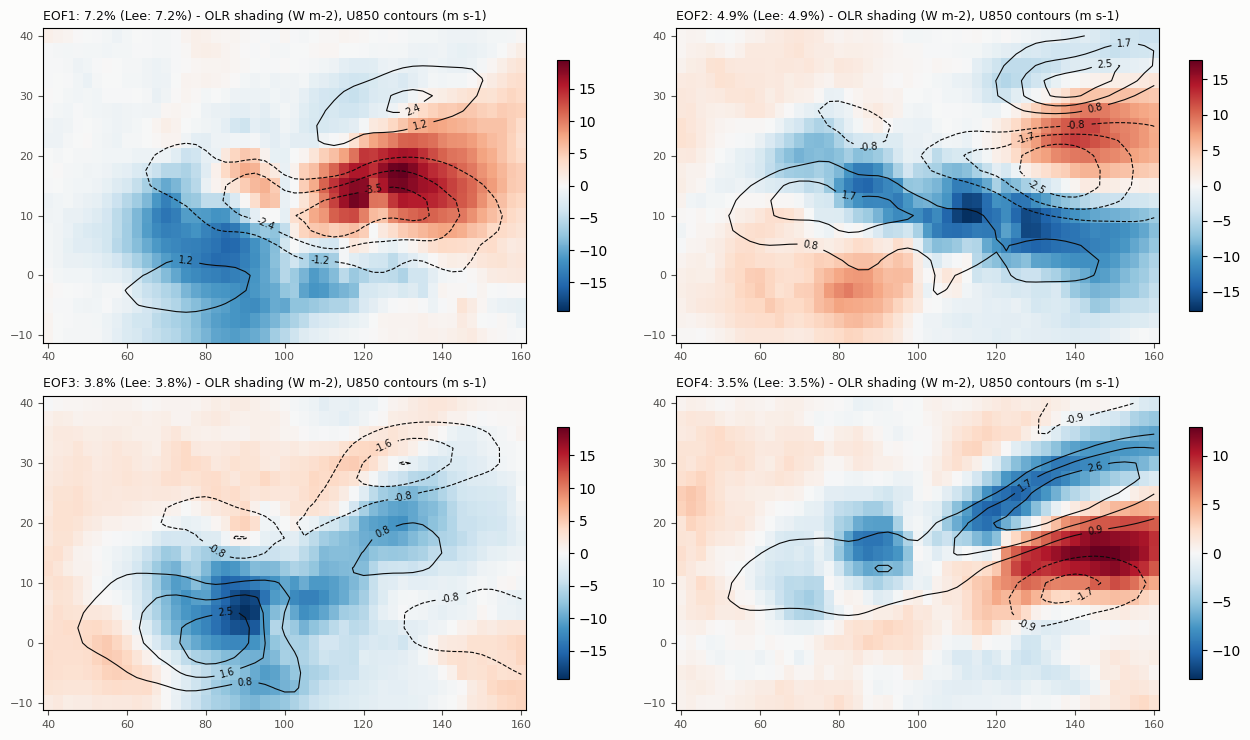

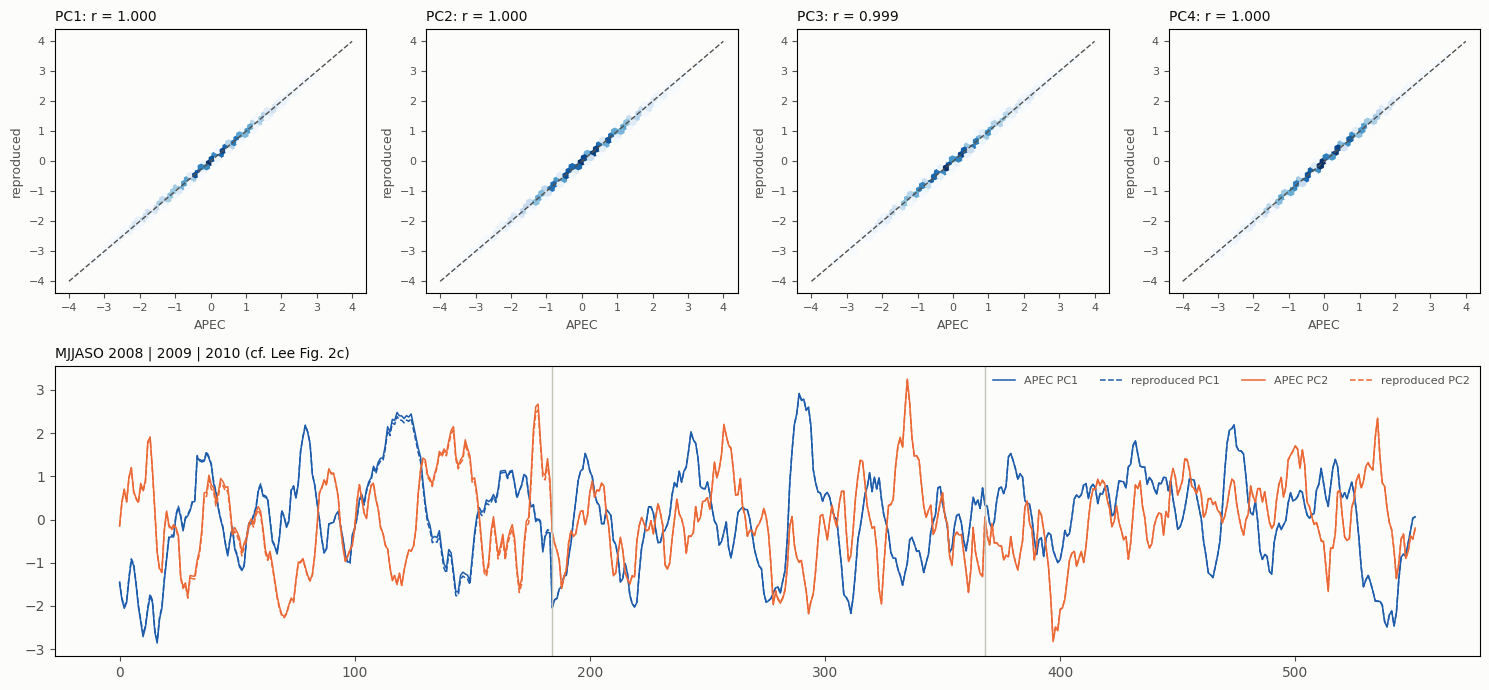

In [7]:
INK, INK2, GRID, BASE, SURF = '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7', '#fcfcfb'
nl, nx = len(lat), len(lon)
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), facecolor=SURF)
for k, ax in enumerate(axes.ravel()):
    ph = best['E'][k] * np.sqrt(best['lam'][k])                    # 1-SD PC, normalised units
    o_map = (ph[:nl * nx] * best['fac']['olr']).reshape(nl, nx)
    u_map = (ph[nl * nx:] * best['fac']['u850']).reshape(nl, nx)
    if best['cfg']['weight'] == 'sqrtcos':
        o_map /= np.sqrt(np.cos(np.deg2rad(lat)))[:, None]; u_map /= np.sqrt(np.cos(np.deg2rad(lat)))[:, None]
    vmax = np.nanmax(np.abs(o_map))
    pc = ax.pcolormesh(lon, lat, o_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='nearest')
    lev = np.linspace(-np.abs(u_map).max(), np.abs(u_map).max(), 9)
    cs = ax.contour(lon, lat, u_map, levels=lev[np.abs(lev) > 1e-6], colors=INK, linewidths=0.8)
    ax.clabel(cs, fontsize=7, fmt='%.1f')
    ax.set_title(f'EOF{k + 1}: {100 * best["frac"][k]:.1f}% (Lee: {LEE["expl_var_pct"][k]}%) - OLR shading (W m-2), '
                 f'U850 contours (m s-1)', loc='left', fontsize=9, color=INK)
    ax.tick_params(colors=INK2, labelsize=8); ax.set_facecolor(SURF)
    fig.colorbar(pc, ax=ax, shrink=0.8)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/bsiso_repro_eofs.png', dpi=150, bbox_inches='tight', facecolor=SURF); plt.show()

fig = plt.figure(figsize=(15, 7), facecolor=SURF)
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.1])
m = PERIODS[p0] & np.isfinite(best['pcn']).all(1) & np.isfinite(OFF).all(1)
for k in range(4):
    ax = fig.add_subplot(gs[0, k])
    ax.hexbin(OFF[m, k], best['pcn'][m, k], gridsize=40, cmap='Blues', mincnt=1)
    ax.plot([-4, 4], [-4, 4], color=INK2, lw=1, ls='--'); ax.set_facecolor(SURF)
    ax.set_title(f'PC{k + 1}: r = {cmp.loc[0, f"r_PC{k + 1}"]:.3f}', loc='left', fontsize=10, color=INK)
    ax.set_xlabel('APEC', color=INK2, fontsize=9); ax.set_ylabel('reproduced', color=INK2, fontsize=9)
    ax.tick_params(colors=INK2, labelsize=8)
ax = fig.add_subplot(gs[1, :])
sel = in_season(dates) & (yrs >= 2008) & (yrs <= 2010)
xs = np.arange(int(sel.sum()))
for k, c in enumerate(['#1c5cab', '#eb6834']):
    ax.plot(xs, OFF[sel, k], color=c, lw=1.1, label=f'APEC PC{k + 1}')
    ax.plot(xs, best['pcn'][sel, k], color=c, lw=1.1, ls='--', label=f'reproduced PC{k + 1}')
for b in (184, 368):
    ax.axvline(b, color=BASE, lw=1)
ax.set_title('MJJASO 2008 | 2009 | 2010 (cf. Lee Fig. 2c)', loc='left', fontsize=10, color=INK)
ax.legend(frameon=False, fontsize=8, ncol=4, labelcolor=INK2); ax.set_facecolor(SURF); ax.tick_params(colors=INK2)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/bsiso_repro_vs_apec.png', dpi=150, bbox_inches='tight', facecolor=SURF)
plt.show()

## Cell 8 — Save the reproduced index (read by nb35 Cell 12)

In [8]:
pcn = best['pcn']
ok = np.isfinite(pcn[:, :2]).all(1)
meta = {'source': 'NOAA interpolated OLR + NCEP-DOE R2 u850 (2.5 deg)', 'method': 'Lee et al. (2013)',
        'eof_sample': 'MJJASO 1981-2010', 'n_fit_days': best['n_fit'], 'config': best['cfg'],
        'expl_var_pct': [round(100 * v, 2) for v in best['frac'][:4]],
        'normalisation': {k: round(v, 4) for k, v in best['fac'].items()},
        'vs_official': cmp.round(4).to_dict(orient='records')}
np.savez_compressed(f'{IDX_DIR}/bsiso_lee_repro.npz', dates=np.asarray(dates.strftime('%Y-%m-%d')),
                    pcs=pcn.astype(np.float32), pcs_raw=best['pcs'].astype(np.float32), eofs=best['E'].astype(np.float32),
                    eigvals=best['lam'], lat=lat, lon=lon,
                    phase=np.where(ok, lee_phase(np.nan_to_num(pcn[:, 0]), np.nan_to_num(pcn[:, 1])), 0),
                    amp=np.hypot(pcn[:, 0], pcn[:, 1]),
                    meta=json.dumps(meta, default=float))
json.dump({'best_variant': BEST, 'paper_vs_repro': val.astype(str).to_dict(orient='records'),
           'vs_official': cmp.round(4).to_dict(orient='records'), 'phase_shift_match': match},
          open(f'{OUT_DIR}/bsiso_validation.json', 'w'), indent=2, default=float)
print('saved bsiso_lee_repro.npz and bsiso_validation.json')

saved bsiso_lee_repro.npz and bsiso_validation.json


---
## Done

- The Cell 4 grid (top rows).
- The two Cell 5 tables.
- The Cell 6 crosstab and the "+2" share.
- `bsiso_repro_eofs.png` and `bsiso_repro_vs_apec.png`.

**How to read it:**
- **r >= 0.99 for PC1-PC4 in MJJASO 1981-2010:** exact reproduction.
- **Normalisation factors near 33.04 / 4.01 and PC SDs near 12.0 / 10.0 / 8.8 / 8.4:** the data and grid match the paper's.
- **The Cell 6 share:** tells whether the project's BSISO phase labels are a +2 relabelling of Lee's.